In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise

/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise


In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time as time
import pandas as pd
import math
import copy
import os

# Nice colours
colorsBlue = ['#b3e5fc', '#0091ea']
colorsRed = ['#f18e86', '#e83b47']
colorsYellow = ['#fb9d32', '#fec787']
colorsPurple = ['#d69bc5' ,'#a8509f']
colorsGreyOrange = ['#c3c3c3', '#f8a834']
colors = [colorsBlue, colorsRed, colorsYellow, colorsPurple, colorsGreyOrange]

# Nice cmap
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', [colors[0][1], 'white', colors[1][1]])

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from utils.dataset import GeneralDataset
from utils.network import MODEL
from utils.graphs import analyse_connectivity
from utils.plots import *
from utils.information_metrics import *

from sklearn.metrics import mutual_info_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics.cluster import adjusted_mutual_info_score

In [5]:
# basic settings
encode_num = 4
decode_num = 4
k = encode_num
hidden_num = 32
LAYER_NUM = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
common_settings = {'L2' : 1e-4, 'bias' : True, 'nonlinear' : True, 'hidden_layer' : LAYER_NUM}
RUN_TYPE = 'nonlinear' # 'linear' for f(x) = x, or 'nonlinear' for randomly generated f(x)

Sinusoidal target functions

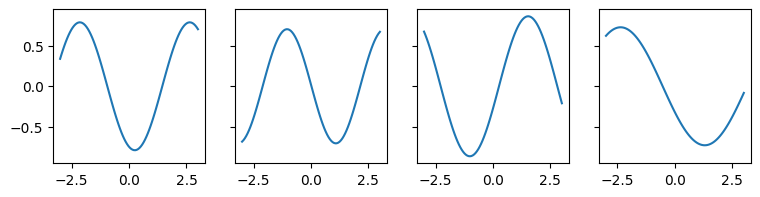

In [7]:
seed = 145
np.random.seed(seed)


# folder = f'results_{RUN_TYPE}'
# os.makedirs(folder, exist_ok = True)

amps = 0.7 + 0.3 * np.random.rand(encode_num) # * ((np.random.rand(encode_num) > 0) - 0.5)
fres = 0.4 + 1.4 * np.random.rand(encode_num) # 0.4, 0.4 for N8 and N16
phis = 2 * np.pi * np.random.rand(encode_num)
def morph(x):
	return amps * np.sin(fres * x + phis)

# plot to-be-learned functions
fig, axes = plt.subplots(1, encode_num, figsize = (9, 2), sharex = True, sharey = True)
xx = np.linspace(-3, 3, 100)
yy = np.array([morph([x] * encode_num) for x in xx])
for i in range(encode_num):
	axes[i].plot(xx, yy[:, i])

Test dataset

In [8]:
test_dataset = GeneralDataset(encode_num = encode_num, mapfun = morph, num_samples = 1000)

Need to create directory

In [9]:
from datetime import datetime

exp_label = "exp32_metrics_iid_n_5_to_255"
date_label = datetime.now().strftime("%Y-%m-%d")

experiment_folder = f"results_{RUN_TYPE}/{date_label}/{exp_label}"

os.makedirs(experiment_folder, exist_ok=True)

Main loop

In [11]:
sample_sizes = [x for x in range(5,256,10)]
seeds = [x for x in range(20)]

conditions = [
    {"name": "iid", "sampling_mode": "random_data", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": None},
    # {"name": "perfect_grid", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "4subgrids_size16", "sampling_mode": "sub_grid_diag", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": 4},
    # {"name": "5subgrids_size16", "sampling_mode": "sub_grid_diag", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": 5},
    #{"name": "base_points_5", "sampling_mode": "base_points", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None},
    # {"name": "perfect_grid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 0},
    #{"name": "5shells_x16", "sampling_mode": "concentric_shells", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": 5, "num_removed": None},
    # {"name": "perfect_delete1", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 1, "add_iid": None},
    # {"name": "perfect_delete2", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 2, "add_iid": None},
    # {"name": "perfect_delete4", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 4, "add_iid": None},
    # {"name": "perfect_delete8", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 8, "add_iid": None},
    # {"name": "perfect_delete16", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 16, "add_iid": None},
    # {"name": "perfect_delete27", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 27, "add_iid": None},
    # {"name": "perfect_delete40", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 40},
    # {"name": "perfect_delete54", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 54},
    # {"name": "perfect_delete64", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0, "num_grids": None, "num_removed": 65},
    # {"name": "grid_and_01_iid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.1, "num_grids": None, "num_removed": 0},
    # {"name": "grid_and_005_iid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.05, "num_grids": None, "num_removed": 0, "add_iid": None},
    # {"name": "grid_and_0025_iid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.025, "num_grids": None, "num_removed": 0, "add_iid": None},
    # {"name": "grid_and_00125_iid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.0125, "num_grids": None, "num_removed": 0, "add_iid": None},
    # {"name": "mi_modulo_q_3", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 3},
    # {"name": "mi_modulo_q_4", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 4},
    # {"name": "mi_modulo_q_5", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 5},
    # {"name": "mi_modulo_q_6", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 6},
    # {"name": "mi_modulo_q_7", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 7},
    # {"name": "mi_modulo_q_8", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 8},
    # {"name": "mi_modulo_q_9", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 9},
    # {"name": "mi_modulo_q_10", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels":10},
    # {"name": "mi_modulo_q_11", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels":11},
    # {"name": "mi_modulo_q_12", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels":12},
    # {"name": "mi_modulo_q_13", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels":13},
    # {"name": "mi_modulo_q_17", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 17},
    # {"name": "mi_modulo_q_21", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 21},
    # {"name": "mi_modulo_q_25", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 25},
    # {"name": "mi_modulo_q_29", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 29},
    # {"name": "mi_modulo_q_33", "sampling_mode": "mi_modular", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None, "mi_mod_levels": 33},
    # {"name": "grid_jitter_00325", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0325, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_003", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.03, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_00275", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0275, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0025", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.025, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_00225", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0225, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_002", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.02, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_00175", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0175, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0015", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.015, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_00125", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0125, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_001", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.01, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0009", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.009, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0008", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.008, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_00075", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0075, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0006", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.006, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0005", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.005, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0004", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.004, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0003", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.003, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0002", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0025, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_jitter_0001", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.001, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "perfect_grid", "sampling_mode": "grid", "shuffle_frac": None, "jitter_frac": 0.0, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": None},
    # {"name": "grid_add_1", "sampling_mode": "grid_additions", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": 1},
    # {"name": "grid_add_2", "sampling_mode": "grid_additions", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": 2},
    # {"name": "grid_add_4", "sampling_mode": "grid_additions", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": 4},
    # {"name": "grid_add_8", "sampling_mode": "grid_additions", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": 8},
    # {"name": "grid_add_16", "sampling_mode": "grid_additions", "shuffle_frac": None, "jitter_frac": None, "iid_frac": None, "num_grids": None, "num_removed": None, "add_iid": 16},
    #{"name": "grid_partial_050iid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.5},
    #{"name": "grid_partial_075iid", "sampling_mode": "grid_partial", "shuffle_frac": None, "jitter_frac": None, "iid_frac": 0.75},
    #{"name": "lin_perm_p0", "sampling_mode": "permuted", "shuffle_frac": 0.0},
    # {"name": "lin_perm_p025", "sampling_mode": "permuted", "shuffle_frac": 0.25},
    # {"name": "lin_perm_p05", "sampling_mode": "permuted", "shuffle_frac": 0.5},
    # {"name": "lin_perm_p075", "sampling_mode": "permuted", "shuffle_frac": 0.75},
    # {"name": "lin_perm_p1", "sampling_mode": "permuted", "shuffle_frac": 1.0},
]

ksg_neighbors = [3,5,7]
mi_widths = [0.03,0.06]
mi_lower = -2.0
mi_upper = 2.0

mi_edges_by_width = {
    width: np.arange(
        mi_lower,
        mi_upper + width,
        width,
        dtype=np.float64
    )
    for width in mi_widths
}

results = []

for n in sample_sizes:
    for s in seeds:
        for cond in conditions:
            print(f"Running n={n}, seed={s}, condition={cond['name']}")
            if cond["num_grids"]:
                if ( n / cond["num_grids"] ) != 16:
                    continue

            result = run_one_experiment(
                name=cond['name'],
                n=n,
                sampling_mode= cond["sampling_mode"],
                shuffle_frac= cond["shuffle_frac"],
                seed=s,
                jitter_frac=cond["jitter_frac"],
                iid_frac = cond["iid_frac"],
                num_grids = cond["num_grids"],
                num_removed = cond["num_removed"],
                add_iid = cond["add_iid"],
                experiment_folder=experiment_folder,
                mi_edges_by_width=mi_edges_by_width,
                mi_mod_levels=cond["mi_mod_levels"],
                ksg_neighbors=ksg_neighbors,
            )
            results.append(result)
            results_df = pd.DataFrame(results)
            results_df.to_csv(experiment_folder + "/results.csv", index=False)


Running n=5, seed=0, condition=iid
Running n=5, seed=1, condition=iid
Running n=5, seed=2, condition=iid
Running n=5, seed=3, condition=iid
Running n=5, seed=4, condition=iid
Running n=5, seed=5, condition=iid
Running n=5, seed=6, condition=iid
Running n=5, seed=7, condition=iid
Running n=5, seed=8, condition=iid
Running n=5, seed=9, condition=iid
Running n=5, seed=10, condition=iid
Running n=5, seed=11, condition=iid
Running n=5, seed=12, condition=iid
Running n=5, seed=13, condition=iid
Running n=5, seed=14, condition=iid
Running n=5, seed=15, condition=iid
Running n=5, seed=16, condition=iid
Running n=5, seed=17, condition=iid
Running n=5, seed=18, condition=iid
Running n=5, seed=19, condition=iid
Running n=15, seed=0, condition=iid
Running n=15, seed=1, condition=iid
Running n=15, seed=2, condition=iid
Running n=15, seed=3, condition=iid
Running n=15, seed=4, condition=iid
Running n=15, seed=5, condition=iid
Running n=15, seed=6, condition=iid
Running n=15, seed=7, condition=iid
Ru

In [10]:
def run_one_experiment(name, n, sampling_mode, shuffle_frac, seed, jitter_frac, iid_frac, experiment_folder, num_grids, num_removed, add_iid, mi_edges_by_width, mi_mod_levels, ksg_neighbors):
    dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            mapfun=morph,
            sampling_mode=sampling_mode,
            shuffle_frac=shuffle_frac,
            seed=seed,
            jitter_frac=jitter_frac,
            iid_frac = iid_frac,
            num_grids=num_grids,
            num_removed=num_removed,
            add_iid=add_iid,
            mi_mod_levels=mi_mod_levels,
        )

    X, Y = dataset.get_all_data()

    X_np = X.detach().cpu().numpy()

    #Save dataset
    dataset_path = (
        experiment_folder
        + f"/datasets/{name}_samples_{len(X_np)}_seed_{seed}.npy"
        )
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    np.save(dataset_path, X_np)

    # Linear Correlation diagnostics
    C = np.corrcoef(X_np, rowvar=False)
    offdiag = C[np.triu_indices_from(C, k=1)]

    mean_abs_corr = np.mean(np.abs(offdiag))
    max_abs_corr = np.max(np.abs(offdiag))

    # Information theory diagnostics
    mi_metrics = {}
    mi_arrays_to_save = {}
    nmi_arith_arrays_to_save = {}
    nmi_joint_arrays_to_save = {}
    adj_mi_arrays_to_save = {}

    for width, bin_edges in mi_edges_by_width.items():
        mi_result = binned_mi_summary(X_np, bin_edges)
        width_label = str(width).replace(".", "p")
        mi_metrics[f"mean_mi_bw_{width_label}"] = mi_result["mi_mean"]
        mi_metrics[f"max_mi_bw_{width_label}"] = mi_result["mi_max"]

        mi_metrics[f"mean_nmi_arith_bw_{width_label}"] = mi_result["nmi_arithm_mean"]
        mi_metrics[f"max_nmi_arith_bw_{width_label}"] = mi_result["nmi_arithm_max"]

        mi_metrics[f"mean_nmi_joint_bw_{width_label}"] = mi_result["nmi_joint_mean"]
        mi_metrics[f"max_nmi_joint_bw_{width_label}"] = mi_result["nmi_joint_max"]

        mi_metrics[f"mean_adj_mi_bw_{width_label}"] = mi_result["adj_mi_mean"]
        mi_metrics[f"max_adj_mi_bw_{width_label}"] = mi_result["adj_mi_max"]
        mi_metrics[f"min_adj_mi_bw_{width_label}"] = mi_result["adj_mi_min"]

        mi_metrics[f"TC_bw_{width_label}"] = mi_result["total_correlation"]
        mi_metrics[f"Norm_TC_bw_{width_label}"] = mi_result["normalized_total_correlation"]

        mi_metrics[f"mean_occupied_bins_bw_{width_label}"] = mi_result["mean_occupied_bins"]
        mi_metrics[f"max_occupied_bins_bw_{width_label}"] = mi_result["max_occupied_bins"]
        mi_metrics[f"min_occupied_bins_bw_{width_label}"] = mi_result["min_occupied_bins"]

        mi_metrics[f"mean_samples_per_occupied_bin_bw_{width_label}"] = mi_result["mean_samples_per_occupied_bin"]
        mi_metrics[f"max_samples_per_occupied_bin_bw_{width_label}"] = mi_result["max_samples_per_occupied_bin"]
        mi_metrics[f"min_samples_per_occupied_bin_bw_{width_label}"] = mi_result["min_samples_per_occupied_bin"]

        # MI matrices to save
        mi_arrays_to_save[f"matrix_bw_{width_label}"] = mi_result["mi_matrix"]
        nmi_arith_arrays_to_save[f"matrix_bw_{width_label}"] = mi_result["nmi_arithm_matrix"]
        nmi_joint_arrays_to_save[f"matrix_bw_{width_label}"] = mi_result["nmi_joint_matrix"]
        adj_mi_arrays_to_save[f"matrix_bw_{width_label}"] = mi_result["adj_mi_matrix"]

        mi_arrays_to_save[f"edges_bw_{width_label}"] = bin_edges
        nmi_arith_arrays_to_save[f"edges_bw_{width_label}"] = bin_edges
        nmi_joint_arrays_to_save[f"edges_bw_{width_label}"] = bin_edges
        adj_mi_arrays_to_save[f"edges_bw_{width_label}"] = bin_edges

    #Save MI matrices
    mi_folder = experiment_folder + f'/mi_matrices'
    os.makedirs(mi_folder, exist_ok = True)

    arith_nmi_folder = experiment_folder + f'/arith_nmi_matrices'
    os.makedirs(arith_nmi_folder, exist_ok = True)

    joint_nmi_folder = experiment_folder + f'/joint_nmi_matrices'
    os.makedirs(joint_nmi_folder, exist_ok = True)

    adj_mi_folder = experiment_folder + f'/adj_mi_matrices'
    os.makedirs(adj_mi_folder, exist_ok = True)

    mi_path = mi_folder + f"/{name}_samples_{len(X_np)}_seed_{seed}_mi.npz"
    arith_nmi_path = arith_nmi_folder + f"/{name}_samples_{len(X_np)}_seed_{seed}_arith_nmi.npz"
    joint_nmi_path = joint_nmi_folder + f"/{name}_samples_{len(X_np)}_seed_{seed}_joint_nmi.npz"
    adj_mi_path = adj_mi_folder + f"/{name}_samples_{len(X_np)}_seed_{seed}_adj_mi.npz"

    np.savez_compressed(
        mi_path,
        **mi_arrays_to_save
    )

    np.savez_compressed(
        arith_nmi_path,
        **nmi_arith_arrays_to_save
    )

    np.savez_compressed(
        joint_nmi_path,
        **nmi_joint_arrays_to_save
    )

    np.savez_compressed(
        adj_mi_path,
        **adj_mi_arrays_to_save
    )

    #Create continuous kNN/KSG-style pairwise MI estimates

    ksg_mi_folder = experiment_folder + f'/ksg_mi_matrices'
    os.makedirs(ksg_mi_folder, exist_ok = True)
    ksg_mi_arrays_to_save = {}

    for neigh in ksg_neighbors:
        if neigh >= len(X_np):
            mi_metrics[f"mean_ksg_mi_neigh_{neigh}"] = np.nan
            mi_metrics[f"max_ksg_mi_neigh_{neigh}"] = np.nan
            continue

        ksg_mi_result = pairwise_ksg_mi_sklearn(X=X_np, n_neighbors=neigh, random_state=seed)
        mi_metrics[f"mean_ksg_mi_neigh_{neigh}"] = ksg_mi_result["ksg_mean"]
        mi_metrics[f"max_ksg_mi_neigh_{neigh}"] = ksg_mi_result["ksg_max"]
        ksg_mi_arrays_to_save[f"matrix_ksg_{neigh}"] = ksg_mi_result["ksg_matrix"]


    ksg_mi_path = ksg_mi_folder + f"/{name}_samples_{len(X_np)}_seed_{seed}_ksg_mi.npz"

    np.savez_compressed(
        ksg_mi_path,
        **ksg_mi_arrays_to_save
    )

    result = {
        "n": len(X_np),
        "condition": name,
        "sampling_mode": sampling_mode,
        "shuffle_frac": shuffle_frac,
        "mean_abs_corr": mean_abs_corr,
        "max_abs_corr": max_abs_corr,
        "seed": seed,
        "jitter":jitter_frac,
        "iid_frac": iid_frac,
        "num_grids": num_grids,
        "num_removed": num_removed,
        "add_iid": add_iid,
        **mi_metrics,
        }

    return result

Train model


In [ ]:
def train_model(dataset, samples, name, experiment_folder, seed):

    train_dataloader = DataLoader(dataset, batch_size = 1100)

    lr = 1e-3
    wd = 0 # using explicit L2 regularisation
    num_epochs = 10000

    settings = [#{'name' : 'Noise0', 'noise_coef' : 0.1, 'noise_expt' : 0},
                #{'name' : 'Noise1', 'noise_coef' : 0.1, 'noise_expt' : 1},
                #{'name' : 'Noise2', 'noise_coef' : 0.1, 'noise_expt' : 2},
                #{'name' : 'L2'},
                #{'name' : 'L1', 'L1': 1e-3},
                #{'name' : 'Act', 'Act' : 1e-3},
                {'name' : 'WeightedAct', 'WeightedAct' : 1e-3},
                #{'name' : 'WeightedActSigmoid', 'WeightedAct' : 1e-3, 'use_sigmoid' : True},
                #{'name' : 'WeightedActTanh', 'WeightedAct' : 1e-3, 'use_tanh' : True},
                ]

    #modify this later if using multiple regularizers
    metrics = {}

    #Maybe put the seed in the folder name if using several seeds
    for setting in settings:
        file_name = setting['name']
        folder = experiment_folder + f'/{file_name}/size_{samples}/mode_{name}/seed_{seed}'
        os.makedirs(folder, exist_ok = True)
        print(f'running setting {file_name}...')


        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        model = MODEL(encode_num = encode_num,
                decode_num = decode_num,
                hidden_num = hidden_num,
                **(setting | common_settings))
        model.to(device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = wd)

        # Training loop
        losses = []
        model.train()
        for epoch in range(num_epochs):
            losses.append(model.fit(train_dataloader, dataset, test_dataset, optimizer, criterion, device))
            print(f'epoch {epoch:07d}, test loss {losses[-1][0]:.5f}, valid vloss {losses[-1][1]:.5f}, L2 norm {losses[-1][3]:.5f}', end = '\r')
        losses = np.array(losses)
        print()

        # plot, analyse, and save miscellaneous stuff
        plot_test(model, test_dataset, device, morph, folder, f'scatter')
        plot_loss(losses, folder, f'losses')
        WMATS, EIG_RAW, EIG, IDX, EIG_GAPS = analyse_connectivity(model, k = encode_num)
        # plot_spectrum(EIG_RAW, folder, f'spectrum_raw')
        plot_spectrum(EIG, folder, f'spectrum')
        plot_connectivity(WMATS, EIG, IDX, k, cmap, folder, f'connectivity')
        plot_eigengaps(EIG_GAPS, folder, f'gaps')
        torch.save(model, f'{folder}/model.pth')
        with open(f'{folder}/losses.npy', 'wb') as f:
            np.save(f, losses)

        metrics = {
            "regularizer": file_name,
            "final_loss_0": float(losses[-1, 0]),
            "final_loss_1": float(losses[-1, 1]),
            "final_l2_norm": float(losses[-1, 3]),
            "min_loss_0": float(np.min(losses[:, 0])),
            "min_loss_1": float(np.min(losses[:, 1])),
            "4th_gap_layer0": float(EIG_GAPS[0][3]),
            "4th_gap_layer1": float(EIG_GAPS[1][3]),
            "4th_gap_layer2": float(EIG_GAPS[2][3]),
            "max_EV_layer3": float( np.max(EIG[3][0]) ),
        }

    return metrics